# Chapter 9 — Ring Network
**Modeling Social Behavior** | Smaldino

---

This notebook translates the `RingNetwork.nlogo` model into Python.

A **ring lattice** is one of the simplest regular network structures:
- All nodes are arranged in a circle.
- Every node connects to its `k/2` nearest neighbors on each side,
  giving each node exactly `k` edges (degree = k).
- The two parameters are `num_nodes` (how many nodes) and `degree` (how many edges per node).

This network serves as the starting point for the small-world algorithm in section 9.3.3.

## 1. Imports

In [1]:
import networkx as nx           # network creation, storage, and analysis
import matplotlib.pyplot as plt # plotting
import numpy as np              # numerical utilities

## 2. Global Parameters

These match the two sliders in the NetLogo model.

**Global variables** — defined once at the top, shared across the whole model:
- `NUM_NODES`: total number of agents (nodes) in the network.
- `DEGREE`: how many edges each node has. Must be even (each node connects
  to `DEGREE/2` neighbors on each side). Capped at `NUM_NODES - 1`.

In [2]:
# --- Global Parameters ---
# These correspond to the two sliders in the NetLogo interface.

NUM_NODES = 11   # number of nodes; NetLogo slider: 6 to 21
DEGREE    = 4    # edges per node; NetLogo slider: 2 to 20 (steps of 2)

## 3. Building the Ring Lattice

### 3.1 `make_ring_lattice()` — the main constructor

This function does the work of both `make-turtles` and `wire` in the NetLogo model:

- **`make-turtles`** in NetLogo: creates `num-nodes` turtles and arranges them
  in a circle. In Python, `networkx` handles node creation — we don't need to
  lay them out spatially until we visualize.

- **`wire`** in NetLogo: iterates over every node `n`, then for each offset `k`
  from 1 to `degree/2`, connects node `n` to node `(n + k) mod num_nodes`.
  The modulo wraps around so the last nodes connect back to the first ones,
  forming a closed ring.

In [3]:
def make_ring_lattice(num_nodes, degree):
    """
    Build a ring lattice network.

    Translates `wire` + `make-turtles` from RingNetwork.nlogo.

    Parameters
    ----------
    num_nodes : int
        Number of nodes in the network.
    degree : int
        Number of edges per node. Must be even. Will be capped at num_nodes - 1.

    Returns
    -------
    G : nx.Graph
        An undirected ring lattice.
    """
    # --- Guard: degree cannot exceed num_nodes - 1 ---
    # NetLogo does: if degree >= num-nodes [set degree num-nodes - 1]
    # A node cannot connect to more nodes than exist in the network.
    if degree >= num_nodes:
        degree = num_nodes - 1

    # --- Create an empty undirected graph and add all nodes ---
    # Nodes are simply labeled 0, 1, 2, ..., num_nodes - 1.
    # This mirrors creating num_nodes turtles with who-numbers 0..N-1.
    G = nx.Graph()
    G.add_nodes_from(range(num_nodes))

    # --- Wire the ring ---
    # Outer loop: iterate over every node n  (NetLogo: `let n 0`, `while [n < count turtles]`)
    for n in range(num_nodes):

        # Inner loop: connect to k = 1, 2, ..., degree/2 neighbors ahead
        # (NetLogo: `let k 1`, `while [k <= degree / 2]`)
        # Each node only wires *forward* (to nodes with higher index mod N),
        # so every edge is created exactly once (no duplicates).
        for k in range(1, degree // 2 + 1):

            # The neighbor is k steps ahead, wrapping around with modulo.
            # This is the ring's defining feature: the last node connects
            # back to the first, closing the loop.
            # NetLogo: `make-edge turtle n turtle ((n + k) mod count turtles)`
            neighbor = (n + k) % num_nodes
            G.add_edge(n, neighbor)

    return G

### 3.2 Build the network with the global parameters

In [4]:
# Build the ring lattice using our global parameters.
# This mirrors clicking the 'setup' button in the NetLogo interface.
G = make_ring_lattice(NUM_NODES, DEGREE)

# Quick summary to verify the structure.
print(f"Nodes : {G.number_of_nodes()}")
print(f"Edges : {G.number_of_edges()}")
print(f"Degree of each node: {[d for _, d in G.degree()]}")
print(f"All nodes have degree {DEGREE}: {all(d == DEGREE for _, d in G.degree())}")

Nodes : 11
Edges : 22
Degree of each node: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
All nodes have degree 4: True


## 4. Visualization

### 4.1 `circular_layout()` — placing nodes on a ring

In NetLogo, `layout-circle (sort turtles) max-pxcor - 1` arranges turtles
in a circle, ordered by their `who` number.

In NetworkX, `nx.circular_layout(G)` does the same thing: it computes
(x, y) coordinates for each node evenly spaced around a circle.

We sort the nodes explicitly to ensure the ordering matches — node 0 at top,
increasing clockwise — which gives the same visual result as NetLogo.

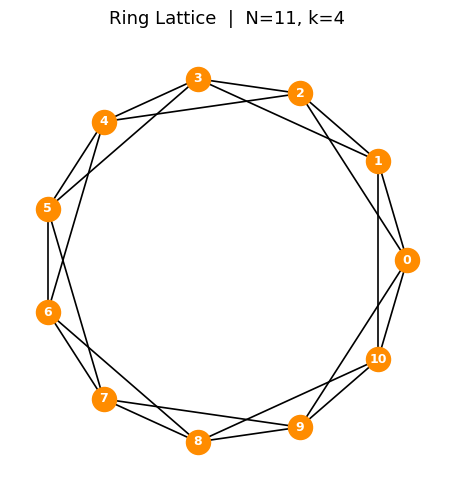

In [5]:
def draw_ring_lattice(G, title="Ring Lattice"):
    """
    Draw a ring lattice with nodes arranged in a circle.

    Replicates the visual output of the NetLogo model:
    orange nodes on a circle, black edges.

    Parameters
    ----------
    G     : nx.Graph  — the ring lattice to draw
    title : str       — plot title
    """
    # Compute circular positions, nodes sorted by label (0, 1, 2, ...).
    # This mirrors `layout-circle (sort turtles)` in NetLogo.
    # Local variable: pos — dict mapping node -> (x, y) coordinates.
    pos = nx.circular_layout(sorted(G.nodes()))

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=13, pad=12)

    # Draw edges first (so nodes render on top).
    # NetLogo: `[set color black]` in make-edge.
    nx.draw_networkx_edges(
        G, pos,
        edge_color='black',
        width=1.2,
        ax=ax
    )

    # Draw nodes.
    # NetLogo: `set color orange`, `set size 1`.
    nx.draw_networkx_nodes(
        G, pos,
        node_color='darkorange',
        node_size=300,
        ax=ax
    )

    # Draw node labels (who numbers).
    nx.draw_networkx_labels(
        G, pos,
        font_color='white',
        font_size=9,
        font_weight='bold',
        ax=ax
    )

    plt.tight_layout()
    plt.show()


# Draw the ring lattice we just built.
draw_ring_lattice(G, title=f"Ring Lattice  |  N={NUM_NODES}, k={DEGREE}")

## 5. Replicating Figure 9.4 — Multiple Degree Values

Figure 9.4 in the book shows ring lattices with N=11 nodes at
k = 2, 4, 6, 8, 10 — reproducing it here is a good way to verify
the model is working correctly across parameter values.

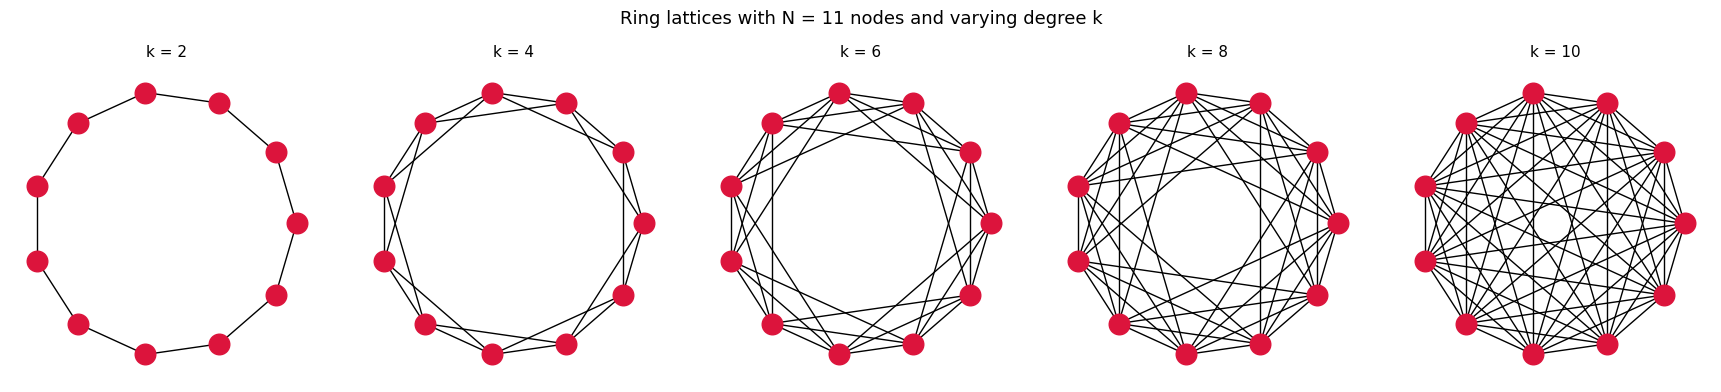

In [6]:
# --- Replicate Figure 9.4 ---
# Local variables: degree_values — list of k values to display.
degree_values = [2, 4, 6, 8, 10]
n_plots = len(degree_values)

fig, axes = plt.subplots(1, n_plots, figsize=(3.5 * n_plots, 3.8))
fig.suptitle("Ring lattices with N = 11 nodes and varying degree k",
             fontsize=13, y=1.02)

for ax, k in zip(axes, degree_values):

    # Build a fresh lattice for this degree value.
    # Local variable: Gk — the ring lattice for degree k.
    Gk  = make_ring_lattice(num_nodes=11, degree=k)
    pos = nx.circular_layout(sorted(Gk.nodes()))

    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f"k = {k}", fontsize=11)

    nx.draw_networkx_edges(Gk, pos, edge_color='black', width=1.0, ax=ax)
    nx.draw_networkx_nodes(Gk, pos, node_color='crimson',
                           node_size=220, ax=ax)

plt.tight_layout()
plt.show()

## 6. Basic Network Metrics

Now that the network is built, we can compute the structural measures
introduced in section 9.1 and 9.3 of the chapter.

In [7]:
def network_metrics(G):
    """
    Compute and print key structural metrics for a network.

    Metrics covered in Chapter 9:
      - Average degree           (section 9.1)
      - Network density          (section 9.1)
      - Average path length      (section 9.3.1)
      - Clustering coefficient   (section 9.3.2)

    Parameters
    ----------
    G : nx.Graph
    """
    # Number of nodes and edges.
    n = G.number_of_nodes()  # local variable
    m = G.number_of_edges()  # local variable

    # Average degree: sum of all degrees / number of nodes.
    # Equivalently: 2m / n (each edge contributes to 2 degrees).
    avg_degree = 2 * m / n

    # Network density: fraction of all possible edges that exist.
    # Possible edges in an undirected graph = n*(n-1)/2.
    density = nx.density(G)

    # Average path length: mean shortest-path distance over all node pairs.
    # Only meaningful if the graph is fully connected (all nodes reachable).
    # For a ring lattice this is always true.
    avg_path_length = nx.average_shortest_path_length(G)

    # Clustering coefficient: average local clustering across all nodes.
    # Each node's local clustering = fraction of its neighbor-pairs
    # that are also connected to each other.
    clustering = nx.average_clustering(G)

    print(f"Nodes                 : {n}")
    print(f"Edges                 : {m}")
    print(f"Average degree ⟨k⟩    : {avg_degree:.3f}")
    print(f"Network density ρ     : {density:.4f}")
    print(f"Average path length L : {avg_path_length:.4f}")
    print(f"Clustering coeff. C   : {clustering:.4f}")


# Compute metrics for our ring lattice.
print(f"=== Ring Lattice  N={NUM_NODES}, k={DEGREE} ===")
network_metrics(G)

=== Ring Lattice  N=11, k=4 ===
Nodes                 : 11
Edges                 : 22
Average degree ⟨k⟩    : 4.000
Network density ρ     : 0.4000
Average path length L : 1.8000
Clustering coeff. C   : 0.5000


## 7. Exploring the Parameter Space

The NetLogo interface lets you drag sliders and click setup to see different
configurations. Here we do the same thing systematically: sweep over
a range of `degree` values and track how the metrics change.

This is a first taste of the kind of parameter sweep that will become
central in the small-world model (section 9.3.3).

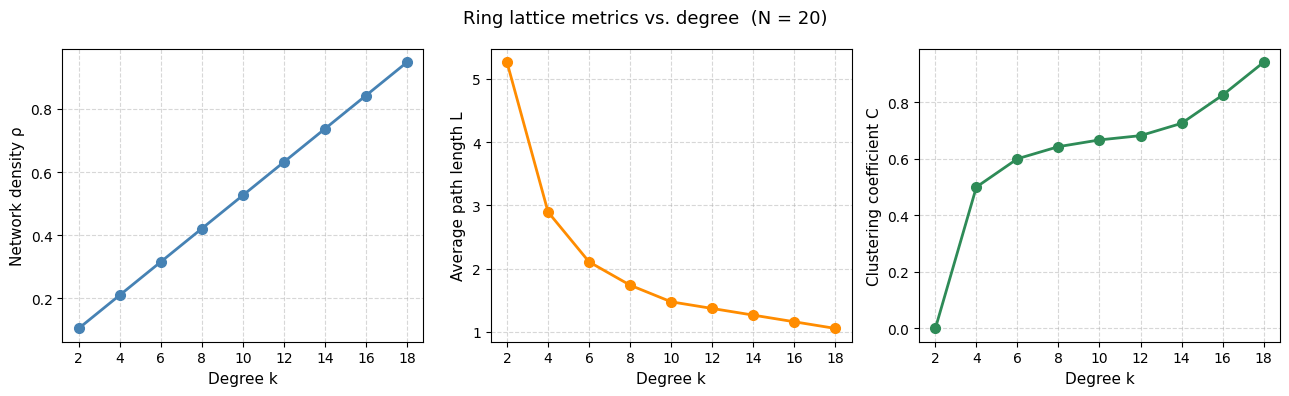

In [8]:
# --- Parameter sweep: vary degree, fix num_nodes ---
# Local variables: results — list of dicts, one per configuration.

N = 20  # fix number of nodes for this sweep

# Degree ranges from 2 to N-1, stepping by 2 (must be even).
# We cap at N-2 to stay even and below N-1.
degree_range = range(2, N, 2)

results = []
for k in degree_range:
    Gk = make_ring_lattice(num_nodes=N, degree=k)
    results.append({
        'degree'          : k,
        'density'         : nx.density(Gk),
        'avg_path_length' : nx.average_shortest_path_length(Gk),
        'clustering'      : nx.average_clustering(Gk),
    })

# Unpack for plotting.
degrees      = [r['degree']          for r in results]
densities    = [r['density']          for r in results]
path_lengths = [r['avg_path_length']  for r in results]
clusterings  = [r['clustering']       for r in results]

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle(f"Ring lattice metrics vs. degree  (N = {N})", fontsize=13)

plot_specs = [
    (densities,    'Network density ρ',         'steelblue'),
    (path_lengths, 'Average path length L',      'darkorange'),
    (clusterings,  'Clustering coefficient C',   'seagreen'),
]

for ax, (values, ylabel, color) in zip(axes, plot_specs):
    ax.plot(degrees, values, 'o-', color=color, lw=2, markersize=7)
    ax.set_xlabel('Degree k', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xticks(degrees)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### What do these plots show?

- **Density** increases linearly with degree — adding more edges fills in a larger fraction of all possible connections.
- **Average path length** decreases as degree increases — when each node has more connections, any two nodes can reach each other in fewer hops.
- **Clustering coefficient** stays relatively high and roughly constant across degree values for a ring lattice. This is a defining feature of regular lattices: the local neighborhood structure is always regular, so neighbors of a node are always connected to each other in a predictable way.

This last point sets up the key contrast with random networks (section 9.2.2), which have *low* clustering but *short* path lengths — the exact opposite profile from a lattice.